In [7]:
import os
import sys
import h5py
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import time
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [8]:
#load file locally
#subhalo_file = r"C:\Users\Mathijs DeKeyser\Documents\TANA\TNG100-1_subhalosCat.hdf5"

#Greg
subhalo_file = r"C:\Users\grego\OneDrive\Documents\ugent\master\2e jaar\TANA paper\TNG100-1_subhalosCat.hdf5 (2)\TNG100-1_subhalosCat.hdf5"

In [9]:
data = h5py.File(subhalo_file, 'r')
data.keys()


<KeysViewHDF5 ['Config', 'Header', 'Parameters', 'Subhalo']>

In [10]:
#All attributes
print("Header")
for x in list(data['Header'].attrs):
    print(f'The value for {x} is: {data['Header'].attrs[x]}')


print("Parameters")
for x in list(data['Parameters'].attrs):
    print(f'The value for {x} is: {data['Parameters'].attrs[x]}')

print("Subhalo")
for x in list(data['Subhalo'].attrs):
    print(f'The value for {x} is: {data['Subhalo'].attrs[x]}')

Header
The value for BoxSize is: 75000.0
The value for HubbleParam is: 0.6774
The value for Nsubgroups_Total is: 4371211
The value for Omega0 is: 0.3089
The value for OmegaLambda is: 0.6911
The value for Redshift is: 2.220446049250313e-16
The value for Time is: 0.9999999999999998
Parameters
The value for AGB_MassTransferOn is: 1
The value for ActivePartFracForNewDomainDecomp is: 0.003
The value for AdaptiveHydroSofteningSpacing is: 1.2
The value for BlackHoleAccretionFactor is: 1.0
The value for BlackHoleCenteringMassMultiplier is: 1000.0
The value for BlackHoleEddingtonFactor is: 1.0
The value for BlackHoleFeedbackFactor is: 0.1
The value for BlackHoleMaxAccretionRadius is: 1e+20
The value for BlackHoleRadiativeEfficiency is: 0.2
The value for BoxSize is: 75000.0
The value for CellMaxAngleFactor is: 2.25
The value for CellShapingSpeed is: 0.5
The value for ComovingIntegrationOn is: 1
The value for CoolingOn is: 1
The value for CoolingTablePath is: b'L75TNG_Arepo_GFM_Tables/Cooling/coo

In [11]:
#information on subhalos

for el in list(data['Subhalo'].keys()):
    print(f"The value of {el} is: {data['Subhalo'][el]}")

The value of SubhaloBHMass is: <HDF5 dataset "SubhaloBHMass": shape (4371211,), type "<f4">
The value of SubhaloBHMdot is: <HDF5 dataset "SubhaloBHMdot": shape (4371211,), type "<f4">
The value of SubhaloBfldDisk is: <HDF5 dataset "SubhaloBfldDisk": shape (4371211,), type "<f4">
The value of SubhaloBfldHalo is: <HDF5 dataset "SubhaloBfldHalo": shape (4371211,), type "<f4">
The value of SubhaloCM is: <HDF5 dataset "SubhaloCM": shape (4371211, 3), type "<f4">
The value of SubhaloFlag is: <HDF5 dataset "SubhaloFlag": shape (4371211,), type "|b1">
The value of SubhaloGasMetalFractions is: <HDF5 dataset "SubhaloGasMetalFractions": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsHalfRad is: <HDF5 dataset "SubhaloGasMetalFractionsHalfRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsMaxRad is: <HDF5 dataset "SubhaloGasMetalFractionsMaxRad": shape (4371211, 10), type "<f4">
The value of SubhaloGasMetalFractionsSfr is: <HDF5 dataset "SubhaloGasMet

In [12]:
#extract useful data
h = data['Header'].attrs['HubbleParam'] #Hubble parameter
boxsize = data['Header'].attrs['BoxSize']/h #boxsize in comoving kpc (~110MPc)
mask   = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) #consider for analysis (halo is suitable for analysis)
pos = np.asarray(data['Subhalo']['SubhaloPos'])/h #kpc most bound particle
COM = np.asarray(data['Subhalo']['SubhaloCM'])/h #COM of halos
total_mass_type = np.asarray(data['Subhalo']["SubhaloMassType"][:])*10**10/h # Total Mass of all bound particles per type
total_mass  = np.asarray(data['Subhalo']["SubhaloMass"][:])*10**10/h  #Total mass of all particles all types combined
subhalo_len = np.asarray(data['Subhalo']["SubhaloLen"][:]) #Total number of member particle/cells in this Subhalo, of all types.
subhalo_parents = np.asarray(data['Subhalo']['SubhaloParent'])
subhalo_grnr = np.asarray(data['Subhalo']['SubhaloGrNr'])
print(len(pos[:,0]))

#only take suitable for analysis (mask 1)
pos = pos[mask==1]
COM = COM[mask == 1]
total_mass_type = total_mass_type[mask == 1]
total_mass = total_mass[mask == 1]
subhalo_len = subhalo_len[mask == 1]
subhalo_parents = subhalo_parents[mask == 1]
subhalo_grnr = subhalo_grnr[mask == 1]

print(len(pos[:,0]))

4371211
4361030


In [13]:
# radius bins for clustering
rmin = 0.01333 * boxsize*h #1Mpc h^-1
rmax = 0.25 * boxsize*h #Distances up to 0.5 are physical, but correlation function drops significantly earlier
nbins = 100
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins +1)

In [14]:
def two_point_tree(positions, rbins, c_boxsize, N_sample = None, verbose = True):

    N_total = len(positions)

      # -------- Downsampling --------
    if N_sample is not None and N_sample < N_total:
        N_sample = int(N_sample)

        idx = np.random.choice(N_total, N_sample, replace=False)
        positions = positions[idx]
    else:
        N_sample = N_total

    # Compute DD
    tree = cKDTree(positions, boxsize=c_boxsize)
    
    # Find all pairs within r_max
    pairs = np.array(list(tree.query_pairs(rbins[-1])), dtype=np.int64)

    # Compute pair separations with periodic BCs
    diffs = positions[pairs[:, 0]] - positions[pairs[:, 1]]
    diffs -= c_boxsize * np.round(diffs / c_boxsize)
    d = np.sqrt((diffs ** 2).sum(axis=1))

    DD, _ = np.histogram(d, bins=rbins )


    # Compute RR
    shell_volumes = (4/3)*np.pi*(rbins[1:]**3 - rbins[:-1]**3)

    RR = ((N_sample * (N_sample - 1)) / 2) * (shell_volumes / c_boxsize**3)

    # Compute xi
    xi = DD / RR - 1

    return dict(xi=xi, DD=DD, RR=RR, rbins=rbins, N=N_sample)


In [15]:
# radius bins for clustering
rmin = 0.0001333 * boxsize*h #0.01MPc h^-1
rmax = 0.1733 * boxsize*h #13 Mpc h^-1 Distances up to 0.5 are physical, but xi drops significantly earlier ()
nbins = 100
#logbins
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins +1)
rmid = np.sqrt(rbins[1:] * rbins[:-1])

In [16]:
#Calculate correlation function

#Only take halos with sufficient star mass to perform analysis
mask = total_mass_type[:,4] >= 10**9
positions_mask = pos[mask]

d0 = time.time()
xires_stars_9_downsampled = two_point_tree(positions_mask*h, rbins, boxsize*h, N_sample = 1e5 , verbose=True)
d1 = time.time()
print('Downsampled pair counting takes:', d1- d0, 's')


Downsampled pair counting takes: 32.11513137817383 s


In [17]:
#Calculate correlation function

#Only take halos with sufficient star mass to perform analysis
mask = total_mass_type[:,4] >= 10**8.5
positions_mask = pos[mask]

d0 = time.time()
xires_stars_downsampled = two_point_tree(positions_mask*h, rbins, boxsize*h, N_sample = 1e5 , verbose=True)
d1 = time.time()
print('Downsampled pair counting takes:', d1- d0, 's')



Downsampled pair counting takes: 79.57116866111755 s


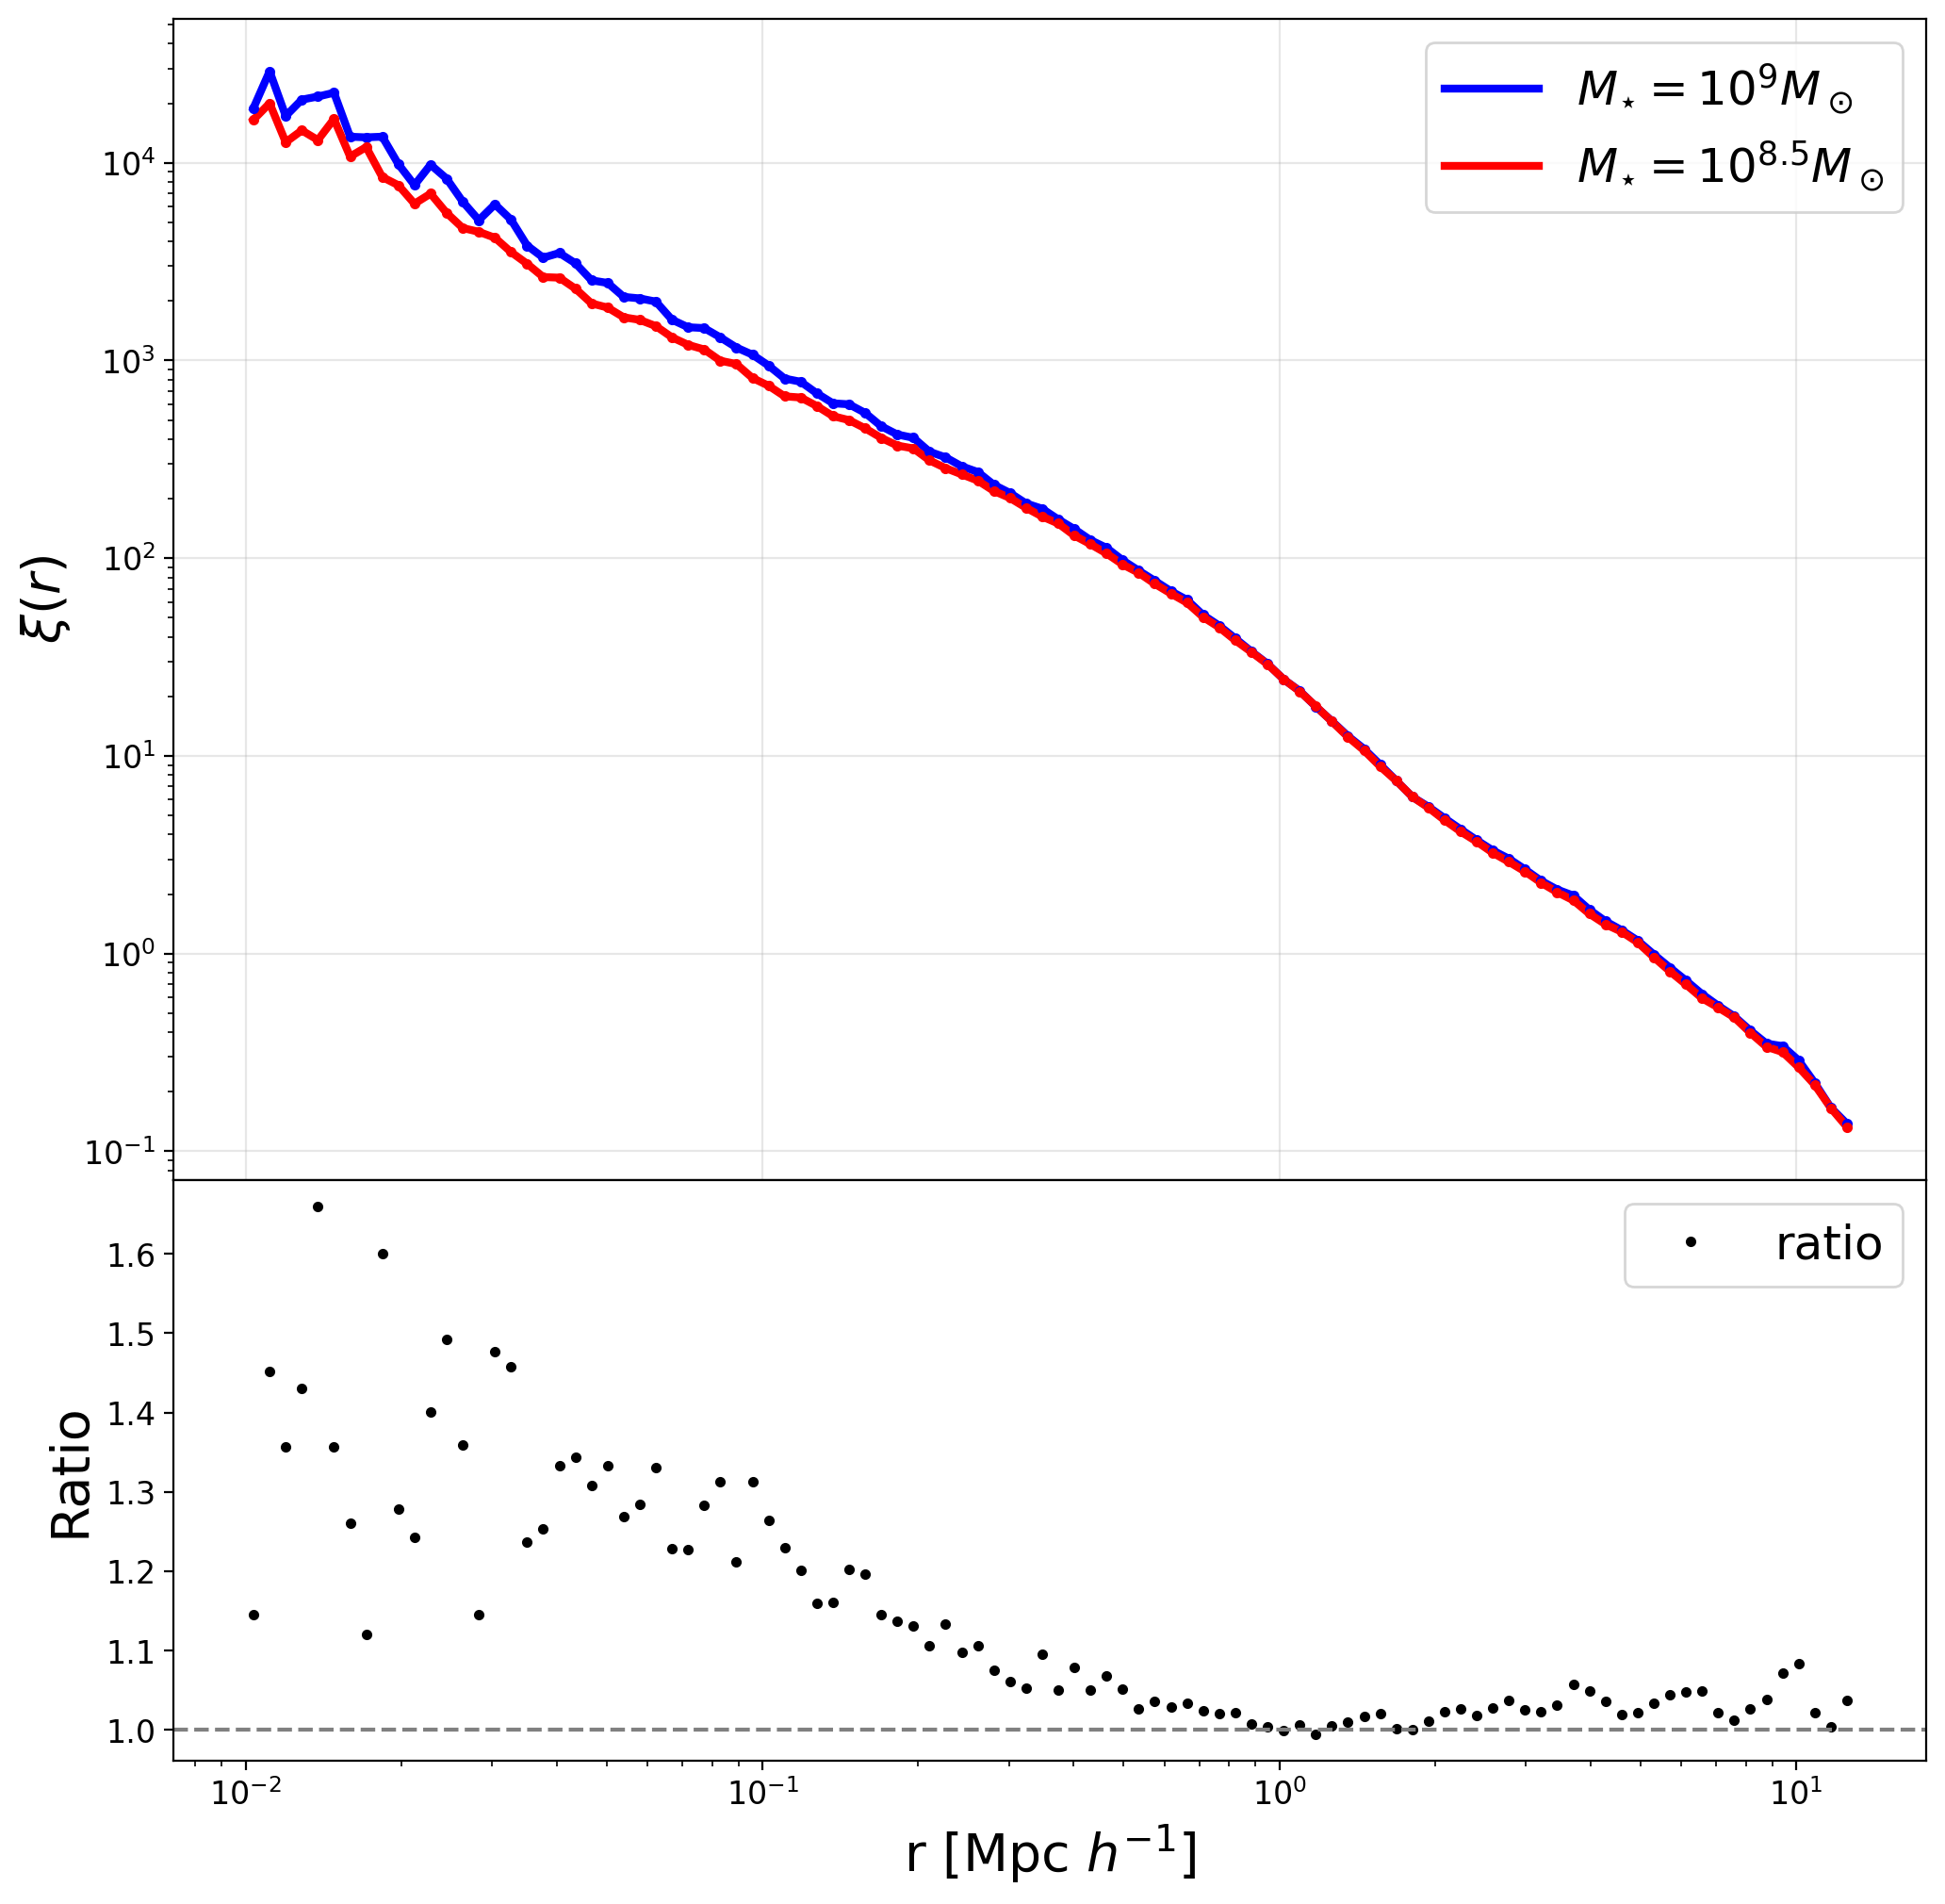

In [29]:

# Create figure with GridSpec
fig = plt.figure(figsize=(12, 12), dpi = 200)
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.0)

#create ratios for lower plot
ratio_N_max = (xires_stars_9_downsampled['xi']/xires_stars_downsampled['xi'])

# Main plot
ax_main = fig.add_subplot(gs[0])
ax_main.plot(rmid/(1000), xires_stars_9_downsampled['xi'], color='blue', lw= 3, label=r'$M_{\star} = 10^9 M_\odot$')
ax_main.plot(rmid/(1000), xires_stars_downsampled["xi"], color='red', label = r'$M_{\star} = 10^{8.5} M_\odot$',lw =3)
ax_main.errorbar(rmid/(1000), xires_stars_9_downsampled["xi"], fmt='o', color='blue', markersize =3)
ax_main.errorbar(rmid/(1000), xires_stars_downsampled["xi"], fmt='o', color='red', markersize = 3)
ax_main.tick_params(axis='both', which='major', labelsize=12)

plt.xscale('log'); plt.yscale('log')
ax_main.set_ylabel(r"$\xi(r)$", fontsize = 20)
plt.grid(alpha=0.3)
plt.legend(fontsize = 18)
ax_main.tick_params(bottom=False)  # remove x-axis ticks for main plot

# Ratio / comparison plot
ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
ax_ratio.plot(rmid/(1000), ratio_N_max, '.', label=r'ratio', color='black')
ax_ratio.axhline(1, color='gray', linestyle='--')
ax_ratio.set_xlabel(r'r [Mpc $h^{-1}$]', fontsize = 20)
ax_ratio.set_ylabel('Ratio', fontsize = 20)
ax_ratio.tick_params(axis='both', which='major', labelsize=12)

# Set desired y-ticks
#ax_ratio.set_yticks([0.7, 0.80, 0.90, 1.00, 1.10,1.2])
#ax_ratio.set_ylim(0.8, 1.2)
ax_ratio.legend(fontsize = 18)

plt.savefig('Images/2PCF.png')
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Parameters
Mtot_min = 1e9                # hard lower cutoff
mass_ratio_thresh = 0.4       # satellite if total_mass / Mcentral < this
fb_thresh = 0.6              # stripped  if baryon fraction > this
min_in_bin = 5                # minimum objects to compute median in a bin
bin_width_dex = 0.5
# ------------------------------------------------

#  Zero mass threshold (also enforce Mtot >= 1e9)
valid = (
    (total_mass > 0)
    & (total_mass_type[:, 1] > Mtot_min)   # dark matter > 0
    & (total_mass_type[:, 4] > 0)   # stars > 0
)

# Extract arrays for valid objects 
Mtot = total_mass[valid]
Mgas = total_mass_type[valid, 0]
Mdm  = total_mass_type[valid, 1]
Mstar = total_mass_type[valid, 4]
parents = subhalo_parents[valid]   # subparent index for valid objects
grnr = subhalo_grnr.astype(np.int64)  # keep full array for group-based ops below

#  simple subparent criterion: centrals 
is_central_subparent = (parents == 0)   

# compute group-central masses using group numbers
grnr_full = subhalo_grnr.astype(np.int64)
if grnr_full.min() == 1:
    grnr_full = grnr_full - 1

N = len(total_mass)
n_groups = grnr_full.max() + 1

# sort by group and by mass to find central per group
sort_idx = np.argsort(grnr_full)
grnr_sorted = grnr_full[sort_idx]
mass_sorted = total_mass[sort_idx]

# group edges and max mass per group
group_edges = np.searchsorted(grnr_sorted, np.arange(n_groups), side='left')
group_edges = np.append(group_edges, N)
max_mass_per_group = np.maximum.reduceat(mass_sorted, group_edges[:-1])

# assign central-group-mass back to each subhalo (unsort)
Mcentral_group = max_mass_per_group[grnr_sorted]
Mcentral_group_unsorted = np.empty_like(Mcentral_group)
Mcentral_group_unsorted[sort_idx] = Mcentral_group
Mcentral_group_full = Mcentral_group_unsorted  # length N, aligned with full arrays

# --- compute group richness (N_group)
group_sizes = np.diff(group_edges)            # number of subhalos in each group 
# map group size back to the full array positions:
group_size_sorted = group_sizes[grnr_sorted]  # length N sorted
group_size_unsorted = np.empty_like(group_size_sorted)
group_size_unsorted[sort_idx] = group_size_sorted
group_size_full = group_size_unsorted       


# --- 3) satellite / stripped classification (on full arrays), then apply valid mask ---
f_mass_full = total_mass / Mcentral_group_full            # mass ratio to group central
fb_full = (total_mass_type[:, 0] + total_mass_type[:, 4]) / total_mass  # baryon fraction

is_central_full = np.zeros(N, dtype=bool)
# find most massive index per group (same as original approach)
central_local = np.full(n_groups, -1, dtype=np.int64)
for g in range(n_groups):
    start, end = group_edges[g], group_edges[g+1]
    if start == end:
        continue
    local_idx = np.argmax(mass_sorted[start:end])
    central_local[g] = start + local_idx
valid_groups = central_local < N
central_indices = sort_idx[central_local[valid_groups]]
is_central_full[central_indices] = True

# Candidates: not central (by group) and mass ratio below threshold
is_sat_candidate_full = (~is_central_full) & (f_mass_full < mass_ratio_thresh)

# Stripped if baryon fraction high (low DM fraction left)
is_stripped_full = (~is_central_full) & (fb_full > fb_thresh)

# Final satellite definition: candidate and not stripped
is_satellite_final_full = is_sat_candidate_full & (~is_stripped_full)

# Apply mask to get centrals/satellites/stripped
valid_idx = np.nonzero(valid)[0]  
is_central_valid_by_group = is_central_full[valid_idx]
is_satellite_valid = is_satellite_final_full[valid_idx]
is_stripped_valid = is_stripped_full[valid_idx]

# now restrict medians to centrals with at least Nmin members
Nmin = 8
group_size_valid = group_size_full[valid_idx]   
is_group_central = is_central_full[valid_idx]   

# Combine with subparent centrals: we keep subparent centrals as centrals regardless of group detection
is_central_final = is_central_subparent | is_central_valid_by_group
# exclude any centrals from the satellite set
is_satellite_final = is_satellite_valid & (~is_central_final)
is_stripped_final = is_stripped_valid & (~is_central_final)

# central candidates to use in medians: centrals and group size >= Nmin OR subparent centrals 
central_for_medians = is_central_final & (group_size_valid >= Nmin)
# alternatively: treat isolated centrals separately
isolated_centrals = is_central_final & (group_size_valid == 1)



# --- 4) build arrays for centrals, satellites, stripped 
Mdm_c = Mdm[central_for_medians]
Mstar_c = Mstar[central_for_medians]
Mgas_c = Mgas[central_for_medians]
Mtot_c = Mtot[central_for_medians]

Mdm_s = Mdm[is_satellite_final]
Mstar_s = Mstar[is_satellite_final]
Mgas_s = Mgas[is_satellite_final]
Mtot_s = Mtot[is_satellite_final]

Mdm_strip = Mdm[is_stripped_final]
Mstar_strip = Mstar[is_stripped_final]
Mgas_strip = Mgas[is_stripped_final]
Mtot_strip = Mtot[is_stripped_final]

#median-with-16/84 function 
def median_with_error(x, y, bin_min=None, bin_max=None, bin_width=bin_width_dex, min_count=min_in_bin):
    if bin_min is None:
        bin_min = np.floor(np.log10(np.nanmin(x)))
    if bin_max is None:
        bin_max = np.ceil(np.log10(np.nanmax(x)))
    edges = 10**np.arange(bin_min, bin_max + 1e-9, bin_width)
    centers = np.sqrt(edges[:-1] * edges[1:])
    med, low, high = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (x > lo) & (x <= hi)
        if np.sum(mask) < min_count:
            med.append(np.nan); low.append(np.nan); high.append(np.nan); continue
        v = y[mask]
        m = np.median(v)
        p16, p84 = np.percentile(v, [16, 84])
        med.append(m); low.append(m - p16); high.append(p84 - m)
    return centers, np.array(med), np.array(low), np.array(high)

# stellar-to-halo ratios
R_c = Mstar_c / Mdm_c
R_s = Mstar_s / Mdm_s

# choose bin range based on centrals 
bin_min = np.floor(np.log10(np.nanmin(Mdm_c))) if len(Mdm_c)>0 else 7
bin_max = np.ceil(np.log10(np.nanmax(Mdm_c))) if len(Mdm_c)>0 else 14

bin_centers, med_c, low_c, high_c = median_with_error(Mdm_c, R_c, bin_min, bin_max)
_, med_s, low_s, high_s = median_with_error(Mdm_s, R_s, bin_min, bin_max)

# baryon fractions
fb_c = (Mstar_c + Mgas_c) / Mtot_c
fb_s = (Mstar_s + Mgas_s) / Mtot_s
_, med_fb_c, low_fb_c, high_fb_c = median_with_error(Mdm_c, fb_c, bin_min, bin_max)
_, med_fb_s, low_fb_s, high_fb_s = median_with_error(Mdm_s, fb_s, bin_min, bin_max)




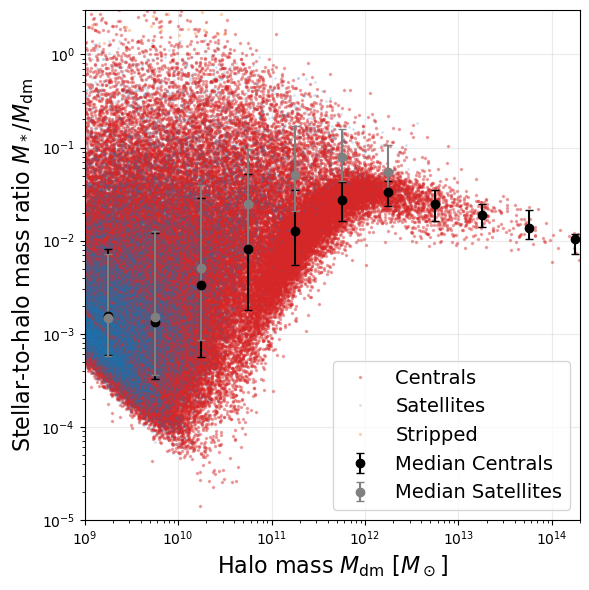

In [33]:
# Plot: Stellar-to-halo mass ratio
plt.figure(figsize=(6,6))
ax = plt.gca()

# raw points
ax.loglog(Mdm_c, R_c, '.', ms=3, alpha=0.35, color='tab:red', label='Centrals ')
ax.loglog(Mdm_s, R_s, '.', ms=2.5, alpha=0.12, color='tab:blue', label='Satellites')
ax.loglog(Mdm_strip, Mstar_strip/Mdm_strip, '.', ms=3, alpha=0.25, color='tab:orange', label='Stripped')

# medians + errorbars (black for centrals, grey for satellites)
ax.errorbar(bin_centers, med_c, yerr=[low_c, high_c],
            fmt='o', color='black', ms=6, capsize=3, label='Median Centrals')
ax.errorbar(bin_centers, med_s, yerr=[low_s, high_s],
            fmt='o', color='grey', ms=6, capsize=3, label='Median Satellites')

ax.set_xlim(1e9, 2e14)
ax.set_ylim(1e-5, 3)
ax.set_xlabel(r"Halo mass $M_{\rm dm}$ [$M_\odot$]", fontsize = 16)
ax.set_ylabel(r"Stellar-to-halo mass ratio $M_*/M_{\rm dm}$", fontsize = 16)
ax.grid(alpha=0.25)
ax.legend(frameon=True, loc='lower right', fontsize = 14)
plt.tight_layout()
plt.savefig("SHMR_improved.png", dpi=300)
plt.show()



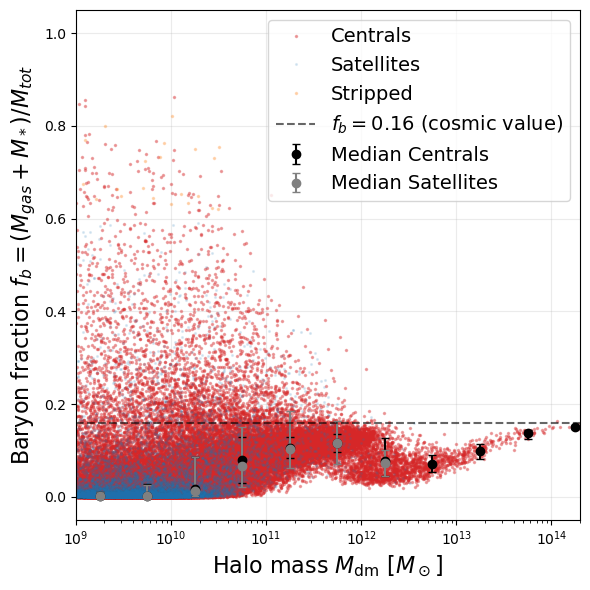

In [34]:
# Plot: Baryon fraction vs halo mass 
plt.figure(figsize=(6,6))
ax = plt.gca()
ax.semilogx(Mdm_c, fb_c, '.', ms=3, alpha=0.35, color='tab:red', label='Centrals')
ax.semilogx(Mdm_s, fb_s, '.', ms=2.5, alpha=0.12, color='tab:blue', label='Satellites')
ax.semilogx(Mdm_strip, (Mstar_strip+Mgas_strip)/Mtot_strip, '.', ms=3, alpha=0.25, color='tab:orange', label='Stripped')

ax.errorbar(bin_centers, med_fb_c, yerr=[low_fb_c, high_fb_c],
            fmt='o', color='black', ms=6, capsize=3, label='Median Centrals')
ax.errorbar(bin_centers, med_fb_s, yerr=[low_fb_s, high_fb_s],
            fmt='o', color='grey', ms=6, capsize=3, label='Median Satellites')

ax.axhline(y=0.16, color='k', ls='--', alpha=0.6, label=r"$f_b = 0.16$ (cosmic value)")

ax.set_xlim(1e9, 2e14)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"Halo mass $M_{\rm dm}$ [$M_\odot$]", fontsize = 16)
ax.set_ylabel(r"Baryon fraction $f_b = (M_{gas}+M_*)/M_{tot}$", fontsize = 16)
ax.grid(alpha=0.25)
ax.legend(frameon=True, loc='upper right', fontsize = 14)
plt.tight_layout()
plt.savefig("BaryonFraction_improved.png", dpi=300)
plt.show()

Best-fit parameters:
N = 2.9414e-02 +/- 1.7599e-04
M1 = 2.129e+11 Msun +/- 4.862e-14
beta = 1.049 +/- 0.040
gamma = 0.296 +/- 0.001


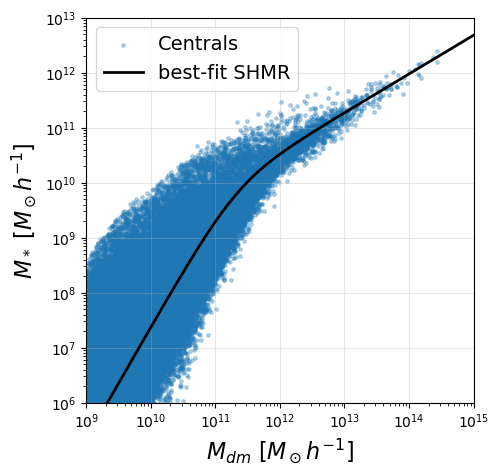

In [35]:
# ----- Define the SHMR function -----
def shmr(Mdm, N, M1, beta, gamma):
    # M200 and M1 in same units (Msun)
    x = Mdm / M1
    return 2.0 * N * Mdm / (x**(-beta) + x**(gamma))

"""
# If you prefer to fit log10(y), wrap the function:
def shmr_log10(M200, N, M1, beta, gamma):
    vals = shmr(M200, N, M1, beta, gamma)
    return np.log10(vals)
"""

# ----- Fit in log space (recommended) -----
xdata = Mtot_c*h
ydata = Mstar_c*h

# initial guesses
p0 = [0.02, 1e12, 1.0, 0.5]  # [N, M1(Msun), beta, gamma]
# bounds to keep physical values (example)
lower = [0, 10**10.5, 0.0, 0.0]
upper = [2.0, 10**12.5, 5.0, 5.0]

# Use curve_fit; fit log10 of the model to ydata
popt, pcov = curve_fit(lambda M, N, M1, beta, gamma: shmr(M, N, M1, beta, gamma),
                       xdata, ydata, p0=p0, bounds=(lower, upper), maxfev=20000)

N_fit, M1_fit, beta_fit, gamma_fit = popt
perr = np.sqrt(np.diag(pcov))

print("Best-fit parameters:")
print("N = {:.4e} +/- {:.4e}".format(N_fit, perr[0]))
print("M1 = {:.3e} Msun +/- {:.3e}".format(M1_fit, perr[1]))
print("beta = {:.3f} +/- {:.3f}".format(beta_fit, perr[2]))
print("gamma = {:.3f} +/- {:.3f}".format(gamma_fit, perr[3]))

# ----- Make a plot -----
Mdm_grid = np.logspace(9, 15, 200)
model_ratio = shmr(Mdm_grid, *popt)

plt.figure(figsize=(5,5))
plt.scatter(xdata, ydata, s=6, alpha=0.3, label='Centrals')
plt.plot(Mdm_grid, model_ratio, lw=2, color='black', label='best-fit SHMR')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$M_{dm}\ [M_\odot h^{-1}]$', fontsize = 16)
plt.ylabel(r'$M_*\ [M_\odot h^{-1}]$', fontsize = 16)
plt.ylim(10**6,10**13)
plt.xlim(10**9,10**15)
plt.legend(fontsize = 14)
plt.grid(alpha=0.3)
plt.savefig("Images/SHMR_fit")
plt.show()

# Wat zien we?

-> Massa resolutie van simulatie is $m_{star} = 1.4 \times 10^6~ M_\odot$ en $m_{dm} = 7.5 \times 10^6 ~M_\odot$\\
Subhalos geven properties van gravitationeel gebonden substructuur van clusters/groepen/halos. Subfind assigned een deeltje aan zijn meest gebonden substructuur, dus *Particle/cells bound to subhaloes of this Subhalo are NOT accounted for.* Structuren met $M \approx 10^{7-8}~M\odot$ bevatten maar enkele deeltjes en zijn gebonden restanten van sattelieten, waarvan DM volledig gestripped is door grotere structuren via tidal stripping. daarom is baryon fractie richting 1 naarmate structuren kleiner worden (sattelieten). tis nice om dit ook uit te leggen da we weten wat de data weergeeft, maar voor echte statisitek & analyse worden die lage massas meestal weggelaten.(miss centrals en sattelites ander kleur in plots?)

Trends: 
Centrals with low-mass halos are less efficient due to stellar feedback, becomes more efficient with mass and peaks at $\approx 10^{12}$, then AGN feedback supresses stellar evolution for the largest galaxies (compare with graph from paper in the cursus)

baryonic fraction almost 1 for low mass sattelites due to DM tidal stripping. for centrals baryonic fraction increases asymptotically towards cosmic fraction $\approx 16\%$ (see 'Feedback reshapes the baryon distribution within haloes, in halo outskirts,
and beyond: the closure radius from dwarfs to massive clusters' for explanation). 

Note bij classificatie central/sattelite: *The values are often zero for all subhalos of a group, indicating that there is no resolved hierarchical structure in that group, beyond the primary subhalo having as direct children all of the secondary subhalos.*

-> Fix betere constraint voor valid halo (papers cutten bij $M_{star} > 10^9$ (~1000 star particles) wat onze data ook deftig maakt, heb nu alles op 1 plot gedaan ma zou sws plot tonen voor alle data en uitleggen waarom die waarden bij 1 liggen/geen dm & dan statische analyse me median enzo uitvoeren op $>10^9$)

Quote from paper [Dark matter stripping in galaxy clusters: a look at the Stellar to Halo Mass relation in the Illustris simulation](https://arxiv.org/pdf/1811.04996):

These two SHMR differ from our measurements at the
two mass extrema. This discrepancy is due to shortcomings
in both calculations. It has been shown (Sawala et al. 2013;
Munshi et al. 2013) that SHMR estimated from dark matter
only simulations (as in Moster et al. 2013) overestimates the
mass of dark matter haloes, especially at low masses, due to
the lack of baryonic physics. However, when correcting for
this difference by matching the subhaloes to their counterpart in Illustris DM-only run, the Illustris simulation still
appears to overpredict the stellar masses of the most and
least massive haloes (Genel et al. 2014; Vogelsberger et al.
2014a). At the high mass end, the prediction of overly massive galaxies could be due to insufficient AGN feedback in
the Illustris samples (eg. Vogelsberger et al. 2014a). At intermediate mass scales, $M∗ ∼ 10^9 − 10^11 h
^{−1}M_\odot$ the measurements are in good agreement

# Part 3)

Possible relations:
- Star formation main sequence (SFR vs M_★)
- Tully Fisher relation

### a) Star Formation Rate (SFR) versus stellar mass

C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:42: RuntimeWarning: divide by zero encountered in log10
  log_med_c = np.log10(med_SFR_central)
C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:43: RuntimeWarning: divide by zero encountered in log10
  log_med_s = np.log10(med_SFR_sat)
C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:46: RuntimeWarning: divide by zero encountered in log10
  log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)
C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:46: RuntimeWarning: invalid value encountered in subtract
  log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)
C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:47: RuntimeWarning: divide by zero encountered in log10
  log_err_high_c = np.log10(med_SFR_central + sigma_high_SFR_central) - log_med_c
C:\Users\grego\AppData\Local\Temp\ipykernel_27632\1759603642.py:47: RuntimeWar

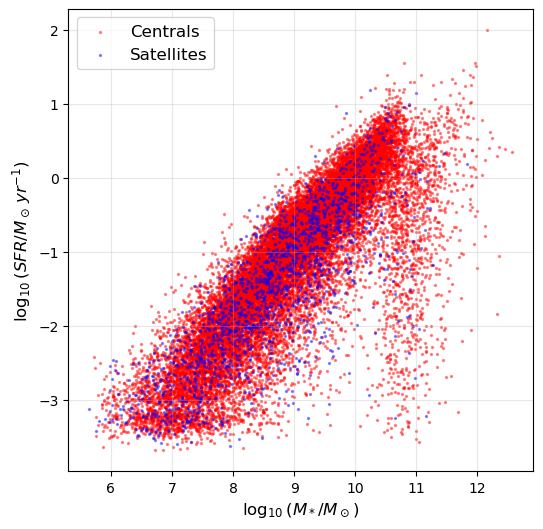

In [23]:
# redefine needed masks
mask_suitable = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8)  # suitable halos

# SFR array
SFR_haloes = np.asarray(data['Subhalo']["SubhaloSFR"])

# Apply masks consistently
SFR_haloes_valid = SFR_haloes[mask_suitable == 1][valid]

SFR_haloes_central = SFR_haloes_valid[central_for_medians]
SFR_haloes_satellites = SFR_haloes_valid[is_satellite_final]

# define bins (based on centrals, as before)
bin_width_dex_SFR = 0.5
logM_min_SFR = np.floor(np.log10(Mstar_c.min()))
logM_max_SFR = np.ceil(np.log10(Mstar_c.max()))
bin_edges_SFR = 10**np.arange(logM_min_SFR, logM_max_SFR + 1e-9, bin_width_dex_SFR)
bin_central_SFR = np.sqrt(bin_edges_SFR[:-1] * bin_edges_SFR[1:])

# median SFRs
bin_centers_SFR, med_SFR_central, sigma_low_SFR_central, sigma_high_SFR_central = \
    median_with_error(Mstar_c, SFR_haloes_central,
                      bin_min=logM_min_SFR, bin_max=logM_max_SFR,
                      bin_width=bin_width_dex_SFR)

_, med_SFR_sat, sigma_low_SFR_sat, sigma_high_SFR_sat = \
    median_with_error(Mstar_s, SFR_haloes_satellites,
                      bin_min=logM_min_SFR, bin_max=logM_max_SFR,
                      bin_width=bin_width_dex_SFR)

# Remove zeros/negatives before log
valid_c = (Mstar_c > 0) & (SFR_haloes_central > 0)
valid_s = (Mstar_s > 0) & (SFR_haloes_satellites > 0)

logMstar_c = np.log10(Mstar_c[valid_c])
logSFR_c   = np.log10(SFR_haloes_central[valid_c])

logMstar_s = np.log10(Mstar_s[valid_s])
logSFR_s   = np.log10(SFR_haloes_satellites[valid_s])

log_bin_centers = np.log10(bin_centers_SFR)
log_med_c = np.log10(med_SFR_central)
log_med_s = np.log10(med_SFR_sat)

# Proper log error propagation (asymmetric)
log_err_low_c  = log_med_c - np.log10(med_SFR_central - sigma_low_SFR_central)
log_err_high_c = np.log10(med_SFR_central + sigma_high_SFR_central) - log_med_c

log_err_low_s  = log_med_s - np.log10(med_SFR_sat - sigma_low_SFR_sat)
log_err_high_s = np.log10(med_SFR_sat + sigma_high_SFR_sat) - log_med_s

# Plot
plt.figure(figsize=(6,6))

plt.scatter(logMstar_c, logSFR_c, s=2, alpha=0.4, color='red', label='Centrals')
plt.scatter(logMstar_s, logSFR_s, s=2, alpha=0.4, color='blue', label='Satellites')

"""
plt.errorbar(log_bin_centers,
             log_med_c,
             yerr=[log_err_low_c, log_err_high_c],
             fmt='o', color='black', capsize=3, label='Median Centrals')

plt.errorbar(log_bin_centers,
             log_med_s,
             yerr=[log_err_low_s, log_err_high_s],
             fmt='o', color='grey', capsize=3, label='Median Satellites')
"""

plt.xlabel(r"$\log_{10}(M_*/M_\odot)$", fontsize=12)
plt.ylabel(r"$\log_{10}(SFR / M_\odot\,yr^{-1})$", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()


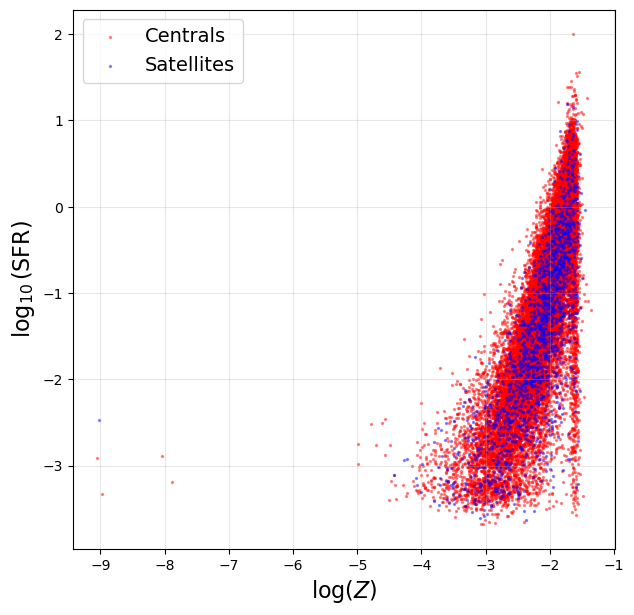

In [36]:
# metallicity and metal fraction
Z_gas = np.asarray(data['Subhalo']["SubhaloGasMetallicity"])
metal_fraction_gas = np.asarray(data['Subhalo']["SubhaloGasMetalFractions"])  # H, He, C, N, O, Ne, Mg, Si, Fe, total_other
Z_stars = np.asarray(data['Subhalo']["SubhaloStarMetallicity"])
metal_fraction_stars = np.asarray(data['Subhalo']["SubhaloStarMetalFractions"])

# apply masks consistently
Z_stars_valid = Z_stars[mask_suitable == 1][valid]

Z_stars_central = Z_stars_valid[central_for_medians]
Z_stars_satellites = Z_stars_valid[is_satellite_final]

# define bins
bin_width_dex_Z = 0.5
logM_min_Z = np.floor(np.log10(Mstar_c.min()))
logM_max_Z = np.ceil(np.log10(Mstar_c.max()))
bin_edges_Z = 10**np.arange(logM_min_Z, logM_max_Z + 1e-9, bin_width_dex_Z)
bin_central_Z = np.sqrt(bin_edges_Z[:-1] * bin_edges_Z[1:])

#central filters
valid_c_ZSFR = (
    (Mstar_c > 0) &
    (Z_stars_central > 0) &
    (SFR_haloes_central > 0)
)

logZ_c   = np.log10(Z_stars_central[valid_c_ZSFR])
logSFR_c = np.log10(SFR_haloes_central[valid_c_ZSFR])

#central satellites
valid_s_ZSFR = (
    (Mstar_s > 0) &
    (Z_stars_satellites > 0) &
    (SFR_haloes_satellites > 0)
)

logZ_s   = np.log10(Z_stars_satellites[valid_s_ZSFR])
logSFR_s = np.log10(SFR_haloes_satellites[valid_s_ZSFR])


# Plot Z–SFR
plt.figure(figsize=(7,7))

plt.scatter(logZ_c, logSFR_c, s=2, alpha=0.4, color='red', label='Centrals')
plt.scatter(logZ_s, logSFR_s, s=2, alpha=0.4, color='blue', label='Satellites')


plt.xlabel(r"$\log(Z)$", fontsize=16)
plt.ylabel(r"$\log_{10}(\mathrm{SFR})$", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=14)
plt.savefig("Images/Z-SFR")
plt.show()


### b) Tully-Fisher relation

### TO DO
- Finalize the errors on slope and intercept
- Check if we have errors from data itself?

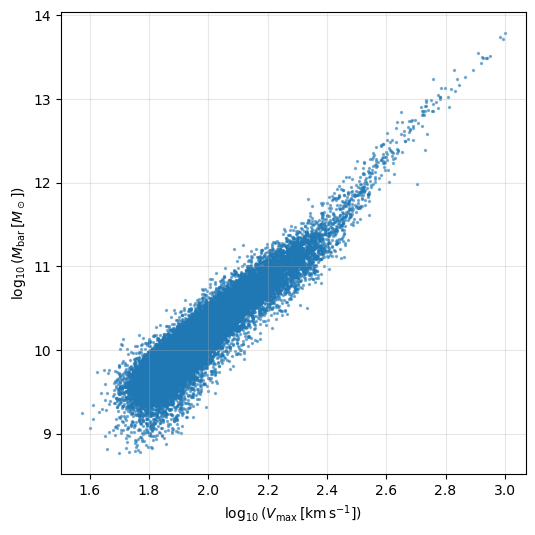

In [25]:
valid = (
    (total_mass > 0)
    & (total_mass_type[:, 1] > Mtot_min)
    & (total_mass_type[:, 4] > 0)
)


mask_suitable = np.asarray(data['Subhalo']['SubhaloFlag'], dtype=np.uint8) == 1

Vmax_full = np.asarray(data['Subhalo']['SubhaloVmax'])[mask_suitable]
SFR_full  = np.asarray(data['Subhalo']['SubhaloSFR'])[mask_suitable]


# Restrict to the same subhalo catalogue as total_mass_type
Vmax = Vmax_full[valid]
SFR  = SFR_full[valid]

Mstar = total_mass_type[valid, 4]
Mgas  = total_mass_type[valid, 0]
Mbar  = Mstar + Mgas

is_central_valid = is_central_full[valid]

# --- Base physical validity
mask_phys = (Mbar > 0) & (Vmax > 0)

Vmax = Vmax[mask_phys]
Mbar = Mbar[mask_phys]
SFR  = SFR[mask_phys]
is_central_phys = is_central_valid[mask_phys]

# --- Select centrals
mask_central = is_central_phys
Vmax_central = Vmax[mask_central]
Mbar_central = Mbar[mask_central]
SFR_central  = SFR[mask_central]

# --- Optional SFR cut (star-forming centrals)
mask_SFR = SFR_central > 0.01
Vmax_central = Vmax_central[mask_SFR]
Mbar_central = Mbar_central[mask_SFR]

# --- Plot baryonic Tully–Fisher relation
plt.figure(figsize=(6,6))
plt.scatter(np.log10(Vmax_central),
            np.log10(Mbar_central),
            s=2, alpha=0.5)

plt.xlabel(r'$\log_{10}(V_{\rm max}\,[\mathrm{km\,s^{-1}}])$')
plt.ylabel(r'$\log_{10}(M_{\rm bar}\,[M_\odot])$')
plt.grid(alpha=0.3)
plt.savefig("Images/TF-relation")
plt.show()


slope = 3.0835 ± 0.0072
intercept = 4.0669 ± 0.0142


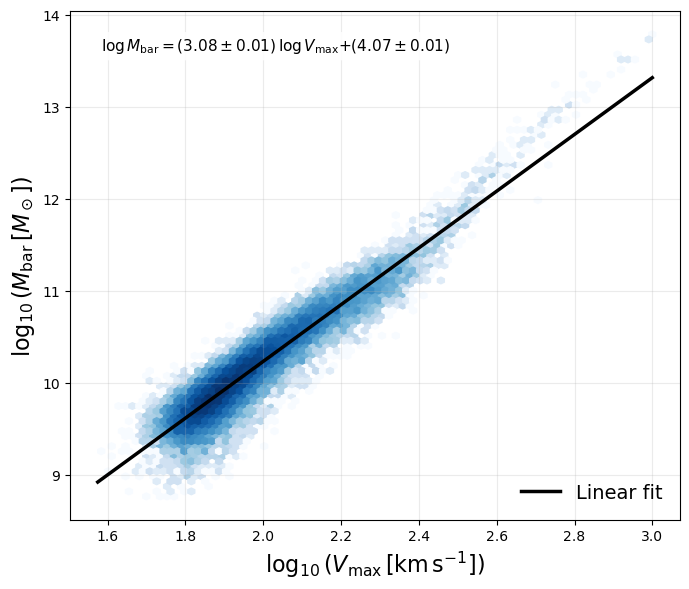

In [37]:
# --- Fit (unchanged)
coeff, cov = np.polyfit(np.log10(Vmax_central),
                        np.log10(Mbar_central),
                        deg=1, cov=True)

slope, intercept = coeff
slope_err, intercept_err = np.sqrt(np.diag(cov))

print(f"slope = {slope:.4f} ± {slope_err:.4f}")
print(f"intercept = {intercept:.4f} ± {intercept_err:.4f}")

x = np.linspace(np.min(np.log10(Vmax_central)),
                np.max(np.log10(Vmax_central)), 200)
y = slope * x + intercept

# --- Plot
plt.figure(figsize=(7,6))

plt.hexbin(np.log10(Vmax_central),
           np.log10(Mbar_central),
           gridsize=80,
           bins='log',
           cmap='Blues')


plt.plot(x, y,
         color="black",
         lw=2.5,
         label="Linear fit")

# Annotation box
text = (
    rf"$\log M_{{\rm bar}} = ({slope:.2f} \pm {slope_err:.2f})\,\log V_{{\rm max}}$"
    rf"$+ ({intercept:.2f} \pm {intercept_err:.2f})$"
)

plt.text(0.05, 0.95, text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="none"))

# Labels
plt.xlabel(r'$\log_{10}(V_{\rm max}\,[\mathrm{km\,s^{-1}}])$', fontsize=16)
plt.ylabel(r'$\log_{10}(M_{\rm bar}\,[M_\odot])$', fontsize=16)

# Cosmetics
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=14, loc= 'lower right')
plt.tight_layout()

plt.savefig("Images/TF-relation-fit", dpi=300)
plt.show()


Our value for TF-relation:
$log_{10}(M_{Bary}/M_{\odot}) = (3.0825\pm0.0072)log_{10}V_{Rot} + (4.0689\pm0.0142)log_{10}M_{\odot}$

Value from [Paper](https://academic.oup.com/mnras/article/520/3/3895/7024877):
$log_{10}(M_{Bary}/M_{\odot}) = (2.94\pm0.23)log_{10}V_{Rot} + (4.15\pm0.44)log_{10}M_{\odot}$

Both values correspond very well